# 02 — Machine Learning: Klasifikasi Sentimen & Emosi
**Proyek:** Analisis Sentimen & Emosi Ulasan E-Commerce Bahasa Indonesia  
**Dataset:** PRDECT-ID Dataset  
**Tim:** Crazy Rich Team — PBA 2026  

---
| Tahap | Isi |
|-------|-----|
| 1 | Setup & Feature Engineering | TF-IDF Vectorization + pipeline setup |
| 2 | Benchmark | Bandingkan 3 model terbaik dengan CV |
| 3 | Evaluasi & Simpan | Confusion Matrix, ROC, save model |

In [1]:
import warnings
import joblib
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, f1_score, accuracy_score
)
from scipy.sparse import vstack as sp_vstack

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

BASE_DIR   = Path.cwd().resolve()
if not (BASE_DIR / ".git").exists():
    BASE_DIR = BASE_DIR.parent
CLEAN_PATH = BASE_DIR / "data" / "clean" / "cleaned_dataset.csv"
MODEL_DIR  = BASE_DIR / "models"
FIG_DIR    = BASE_DIR / "data" / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

import sklearn
print(f"numpy {np.__version__} | sklearn {sklearn.__version__}")
print(f"Model dir : {MODEL_DIR.resolve()}")

numpy 2.4.4 | sklearn 1.7.0
Model dir : D:\pba2026-crazyrichteam\models


In [2]:
# load cleaned dataset hasil notebook 01
df = pd.read_csv(CLEAN_PATH, encoding="utf-8-sig")

# hapus review kosong
df = df[df["clean_review"].notna() & (df["clean_review"].str.strip() != "")].reset_index(drop=True)

EMOTION_NAMES = {0: "Happy", 1: "Sadness", 2: "Fear", 3: "Love", 4: "Anger"}

print(f"Dataset: {df.shape[0]:,} baris, {df.shape[1]} kolom")
print(f"\nDistribusi Sentimen:\n{df['Sentiment'].value_counts().to_string()}")
print(f"\nDistribusi Emosi:\n{df['Emotion'].value_counts().to_string()}")
df[["clean_review", "Sentiment", "Emotion"]].head(3)

Dataset: 5,386 baris, 13 kolom

Distribusi Sentimen:
Sentiment
Negative    2814
Positive    2572

Distribusi Emosi:
Emotion
Happy      1765
Sadness    1201
Fear        916
Love        807
Anger       697


,clean_review,Sentiment,Emotion
0,alhamdulillah fungsi packaging aman respons ce...,Positive,Happy
1,barang bagus respons cepat harga saing,Positive,Happy
2,barang bagus fungsi seler ramah kirim cepat,Positive,Happy


In [3]:
# split 80/20 stratified
X = df["clean_review"]
y_sent = df["sentiment_label"].values
y_emo  = df["emotion_label"].values

X_train, X_test, ys_train, ys_test = train_test_split(
    X, y_sent, test_size=0.2, random_state=RANDOM_SEED, stratify=y_sent
)
_, _, ye_train, ye_test = train_test_split(
    X, y_emo, test_size=0.2, random_state=RANDOM_SEED, stratify=y_emo
)

# TF-IDF — fit hanya pada train agar tidak data leakage
tfidf = TfidfVectorizer(
    max_features  = 5000,
    ngram_range   = (1, 2),
    min_df        = 3,
    sublinear_tf  = True,
    norm          = "l2",
    token_pattern = r"\b[a-zA-Z]{2,}\b",
)

X_train_tf = tfidf.fit_transform(X_train)
X_test_tf  = tfidf.transform(X_test)

joblib.dump(tfidf, MODEL_DIR / "tfidf_vectorizer.pkl")

print(f"Train : {X_train_tf.shape}")
print(f"Test  : {X_test_tf.shape}")
print(f"Vocab : {len(tfidf.vocabulary_):,} fitur")
print(f"Sparsity : {1 - X_train_tf.nnz/(X_train_tf.shape[0]*X_train_tf.shape[1]):.1%}")
print("vectorizer disimpan ke models/tfidf_vectorizer.pkl")

Train : (4308, 3162)
Test  : (1078, 3162)
Vocab : 3,162 fitur
Sparsity : 99.7%
vectorizer disimpan ke models/tfidf_vectorizer.pkl


In [4]:
# definisi kandidat model
CANDIDATES = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight="balanced"),
    "Linear SVC"         : CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_SEED, class_weight="balanced")),
    "Complement NB"      : ComplementNB(),
    "Ridge Classifier"   : CalibratedClassifierCV(RidgeClassifier(class_weight="balanced")),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, class_weight="balanced", n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# benchmark sentimen
print("Benchmarking SENTIMEN (5-fold CV)...")
sent_results = {}
for name, model in CANDIDATES.items():
    try:
        scores = cross_validate(model, X_train_tf, ys_train, cv=cv,
                                scoring=["accuracy", "f1_macro", "roc_auc"], n_jobs=-1)
        sent_results[name] = {
            "Accuracy" : scores["test_accuracy"].mean(),
            "F1-macro" : scores["test_f1_macro"].mean(),
            "AUC"      : scores["test_roc_auc"].mean(),
            "F1±"      : scores["test_f1_macro"].std(),
        }
        r = sent_results[name]
        print(f"  {name:<22} Acc={r['Accuracy']:.4f}  F1={r['F1-macro']:.4f}  AUC={r['AUC']:.4f}")
    except Exception as e:
        print(f"  {name:<22} ERROR: {e}")

df_sent_lb = pd.DataFrame(sent_results).T.sort_values("F1-macro", ascending=False)
print("\nLeaderboard Sentimen:")
display(df_sent_lb.round(4))

Benchmarking SENTIMEN (5-fold CV)...


  Logistic Regression    Acc=0.9088  F1=0.9084  AUC=0.9671


  Linear SVC             Acc=0.9123  F1=0.9119  AUC=0.9688


  Complement NB          Acc=0.9092  F1=0.9091  AUC=0.9705


  Ridge Classifier       Acc=0.9141  F1=0.9138  AUC=0.9699


  Random Forest          Acc=0.8881  F1=0.8880  AUC=0.9565

Leaderboard Sentimen:


,Accuracy,F1-macro,AUC,F1±
Ridge Classifier,0.9141,0.9138,0.9699,0.0093
Linear SVC,0.9123,0.9119,0.9688,0.0117
Complement NB,0.9092,0.9091,0.9705,0.0070
Logistic Regression,0.9088,0.9084,0.9671,0.0147
Random Forest,0.8881,0.8880,0.9565,0.0059


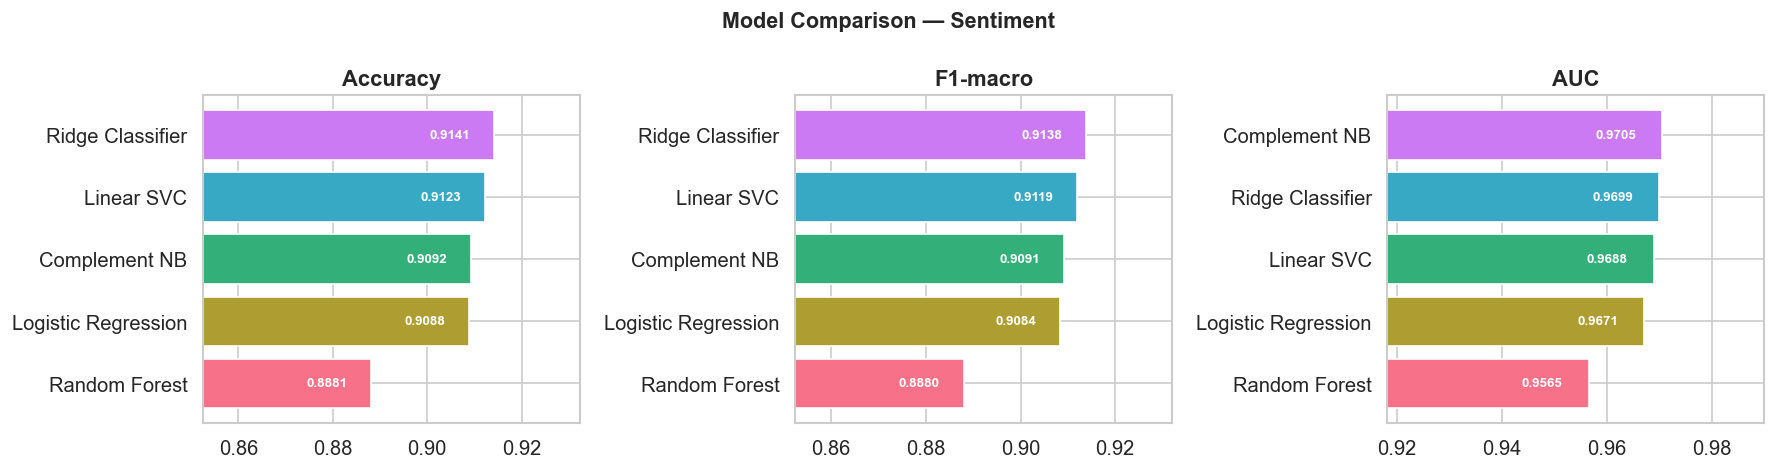

Top-3 Sentimen:
  #1 Ridge Classifier       F1=0.9138  Acc=0.9141  AUC=0.9699
  #2 Linear SVC             F1=0.9119  Acc=0.9123  AUC=0.9688
  #3 Complement NB          F1=0.9091  Acc=0.9092  AUC=0.9705


In [5]:
# visualisasi leaderboard sentimen
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Model Comparison — Sentiment", fontsize=13, fontweight="bold")

palette = sns.color_palette("husl", len(df_sent_lb))
for ax, m in zip(axes, ["Accuracy", "F1-macro", "AUC"]):
    s = df_sent_lb.sort_values(m)
    bars = ax.barh(s.index, s[m], color=palette)
    ax.set_xlim(s[m].min() * 0.96, s[m].max() * 1.02)
    ax.set_title(m, fontweight="bold")
    for bar, val in zip(bars, s[m]):
        ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", ha="right", va="center", fontsize=8, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "13_sentiment_model_comparison.png", bbox_inches="tight")
plt.show()

top3_sent = df_sent_lb.index[:3].tolist()
print("Top-3 Sentimen:")
for i, n in enumerate(top3_sent):
    r = df_sent_lb.loc[n]
    print(f"  #{i+1} {n:<22} F1={r['F1-macro']:.4f}  Acc={r['Accuracy']:.4f}  AUC={r['AUC']:.4f}")

In [6]:
# benchmark emosi (5 kelas)
CANDIDATES_EMO = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight="balanced"),
    "Linear SVC"         : CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_SEED, class_weight="balanced")),
    "Complement NB"      : ComplementNB(),
    "Ridge Classifier"   : CalibratedClassifierCV(RidgeClassifier(class_weight="balanced")),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, class_weight="balanced", n_jobs=-1),
}

print("Benchmarking EMOSI (5-fold CV, 5 kelas)...")
emo_results = {}
for name, model in CANDIDATES_EMO.items():
    try:
        scores = cross_validate(model, X_train_tf, ye_train, cv=cv,
                                scoring=["accuracy", "f1_macro"], n_jobs=-1)
        emo_results[name] = {
            "Accuracy" : scores["test_accuracy"].mean(),
            "F1-macro" : scores["test_f1_macro"].mean(),
            "F1±"      : scores["test_f1_macro"].std(),
        }
        r = emo_results[name]
        print(f"  {name:<22} Acc={r['Accuracy']:.4f}  F1={r['F1-macro']:.4f}")
    except Exception as e:
        print(f"  {name:<22} ERROR: {e}")

df_emo_lb = pd.DataFrame(emo_results).T.sort_values("F1-macro", ascending=False)
print("\nLeaderboard Emosi:")
display(df_emo_lb.round(4))

Benchmarking EMOSI (5-fold CV, 5 kelas)...
  Logistic Regression    Acc=0.2066  F1=0.1968


  Linear SVC             Acc=0.3278  F1=0.0987
  Complement NB          Acc=0.2303  F1=0.2004
  Ridge Classifier       Acc=0.3278  F1=0.0987


  Random Forest          Acc=0.2878  F1=0.1794

Leaderboard Emosi:


,Accuracy,F1-macro,F1±
Complement NB,0.2303,0.2004,0.0118
Logistic Regression,0.2066,0.1968,0.0095
Random Forest,0.2878,0.1794,0.0087
Linear SVC,0.3278,0.0987,0.0001
Ridge Classifier,0.3278,0.0987,0.0001


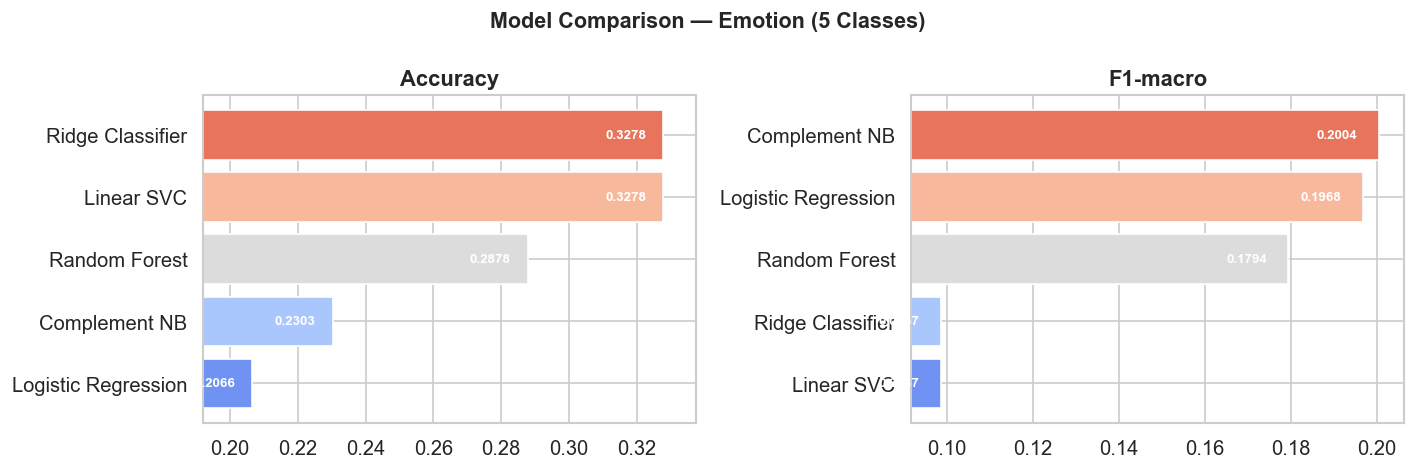

Top-3 Emosi:
  #1 Complement NB          F1=0.2004  Acc=0.2303
  #2 Logistic Regression    F1=0.1968  Acc=0.2066
  #3 Random Forest          F1=0.1794  Acc=0.2878


In [7]:
# visualisasi leaderboard emosi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model Comparison — Emotion (5 Classes)", fontsize=13, fontweight="bold")

palette_emo = sns.color_palette("coolwarm", len(df_emo_lb))
for ax, m in zip(axes, ["Accuracy", "F1-macro"]):
    s = df_emo_lb.sort_values(m)
    bars = ax.barh(s.index, s[m], color=palette_emo)
    ax.set_xlim(s[m].min() * 0.93, s[m].max() * 1.03)
    ax.set_title(m, fontweight="bold")
    for bar, val in zip(bars, s[m]):
        ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", ha="right", va="center", fontsize=8, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "14_emotion_model_comparison.png", bbox_inches="tight")
plt.show()

top3_emo = df_emo_lb.index[:3].tolist()
print("Top-3 Emosi:")
for i, n in enumerate(top3_emo):
    r = df_emo_lb.loc[n]
    print(f"  #{i+1} {n:<22} F1={r['F1-macro']:.4f}  Acc={r['Accuracy']:.4f}")

In [8]:
# tuning & evaluasi model terbaik sentimen
best_sent_name = top3_sent[0]
print(f"Tuning best sentiment model: {best_sent_name}")

param_grids = globals().get("PARAM_GRIDS", {})
param_grid_sent = param_grids.get(best_sent_name, {})
if param_grid_sent:
    search_sent = RandomizedSearchCV(
        CANDIDATES[best_sent_name], param_grid_sent,
        n_iter=15, cv=cv, scoring="f1_macro",
        random_state=RANDOM_SEED, n_jobs=-1, verbose=0
    )
    search_sent.fit(X_train_tf, ys_train)
    tuned_sent = search_sent.best_estimator_
    print(f"  Best params : {search_sent.best_params_}")
    print(f"  Best CV F1  : {search_sent.best_score_:.4f}")
else:
    CANDIDATES[best_sent_name].fit(X_train_tf, ys_train)
    tuned_sent = CANDIDATES[best_sent_name]

y_pred_sent = tuned_sent.predict(X_test_tf)
y_prob_sent = tuned_sent.predict_proba(X_test_tf)[:, 1]

f1_sent  = f1_score(ys_test, y_pred_sent, average="macro")
acc_sent = accuracy_score(ys_test, y_pred_sent)
auc_sent = roc_auc_score(ys_test, y_prob_sent)

print(f"=== Classification Report — Sentimen ({best_sent_name}) ===")
print(classification_report(ys_test, y_pred_sent, target_names=["Negative", "Positive"]))
print(f"F1-macro : {f1_sent:.4f}")
print(f"Accuracy : {acc_sent:.4f}")
print(f"AUC-ROC  : {auc_sent:.4f}")

Tuning best sentiment model: Ridge Classifier
=== Classification Report — Sentimen (Ridge Classifier) ===
              precision    recall  f1-score   support

    Negative       0.91      0.92      0.91       563
    Positive       0.91      0.90      0.90       515

    accuracy                           0.91      1078
   macro avg       0.91      0.91      0.91      1078
weighted avg       0.91      0.91      0.91      1078

F1-macro : 0.9098
Accuracy : 0.9100
AUC-ROC  : 0.9650


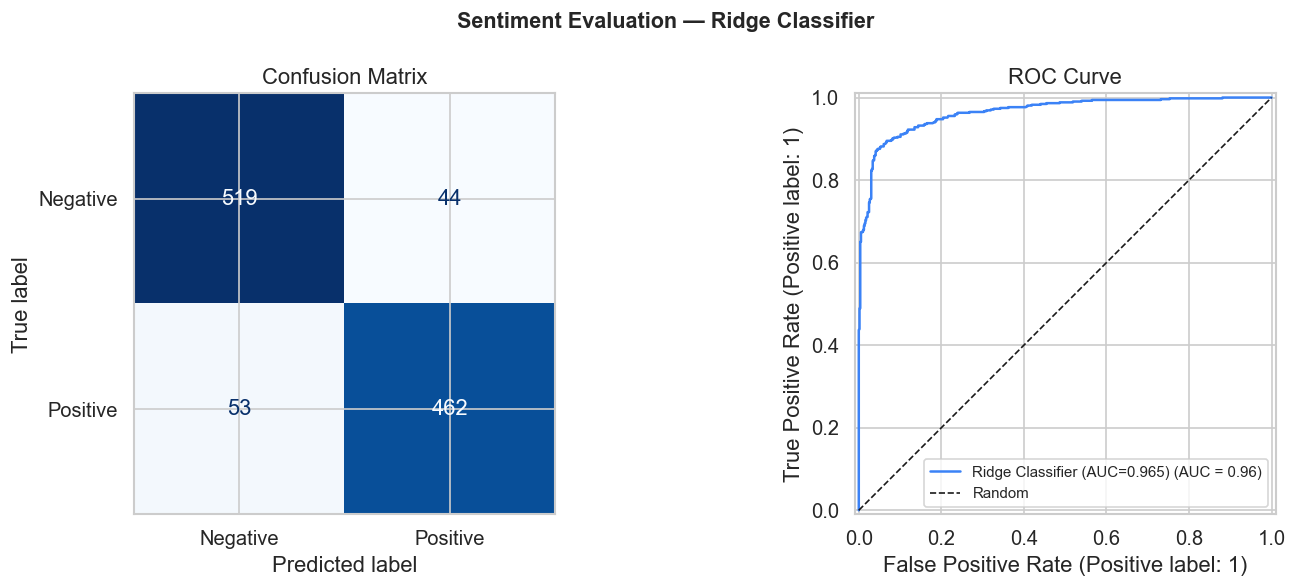

In [9]:
# confusion matrix + ROC sentimen
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Sentiment Evaluation — {best_sent_name}", fontsize=13, fontweight="bold")

cm = confusion_matrix(ys_test, y_pred_sent)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(
    ys_test, y_prob_sent,
    name=f"{best_sent_name} (AUC={auc_sent:.3f})",
    ax=axes[1], color="#3B82F6"
)
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[1].set_title("ROC Curve")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "15_sentiment_confusion_roc.png", bbox_inches="tight")
plt.show()

In [10]:
# tuning & evaluasi model terbaik emosi
best_emo_name = top3_emo[0]
print(f"Tuning model terbaik emosi: {best_emo_name}")

param_grids = globals().get("PARAM_GRIDS", {})
param_grid_emo = param_grids.get(best_emo_name, {})
if param_grid_emo:
    search_emo = RandomizedSearchCV(
        CANDIDATES_EMO[best_emo_name], param_grid_emo,
        n_iter=15, cv=cv, scoring="f1_macro",
        random_state=RANDOM_SEED, n_jobs=-1, verbose=0
    )
    search_emo.fit(X_train_tf, ye_train)
    tuned_emo = search_emo.best_estimator_
    print(f"  Best params : {search_emo.best_params_}")
    print(f"  Best CV F1  : {search_emo.best_score_:.4f}")
else:
    CANDIDATES_EMO[best_emo_name].fit(X_train_tf, ye_train)
    tuned_emo = CANDIDATES_EMO[best_emo_name]

y_pred_emo = tuned_emo.predict(X_test_tf)
f1_emo     = f1_score(ye_test, y_pred_emo, average="macro")
acc_emo    = accuracy_score(ye_test, y_pred_emo)

print(f"\n=== Classification Report — Emosi ({best_emo_name}) ===")
print(classification_report(ye_test, y_pred_emo, target_names=list(EMOTION_NAMES.values())))
print(f"F1-macro : {f1_emo:.4f}")
print(f"Accuracy : {acc_emo:.4f}")

Tuning model terbaik emosi: Complement NB

=== Classification Report — Emosi (Complement NB) ===
              precision    recall  f1-score   support

       Happy       0.33      0.39      0.36       353
     Sadness       0.22      0.21      0.21       240
        Fear       0.21      0.21      0.21       183
        Love       0.14      0.11      0.12       162
       Anger       0.08      0.07      0.08       140

    accuracy                           0.24      1078
   macro avg       0.20      0.20      0.20      1078
weighted avg       0.23      0.24      0.23      1078

F1-macro : 0.1965
Accuracy : 0.2365


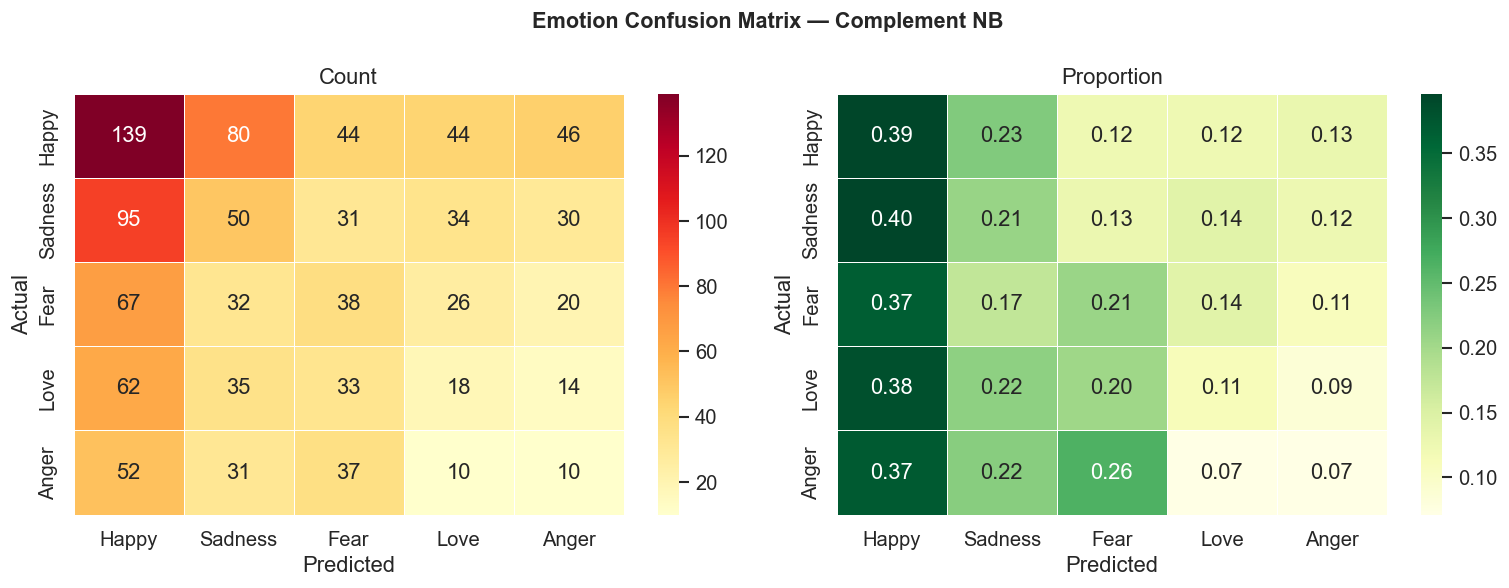

In [11]:
# confusion matrix emosi
cm_emo      = confusion_matrix(ye_test, y_pred_emo)
cm_emo_norm = cm_emo.astype(float) / cm_emo.sum(axis=1, keepdims=True)
labels      = list(EMOTION_NAMES.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Emotion Confusion Matrix — {best_emo_name}", fontsize=13, fontweight="bold")

sns.heatmap(cm_emo, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Count")

sns.heatmap(cm_emo_norm, annot=True, fmt=".2f", cmap="YlGn",
            xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Proportion")

plt.tight_layout()
plt.savefig(FIG_DIR / "16_emotion_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [12]:
# ringkasan akhir
print("=" * 60)
print("  TOP-3 MODEL — SENTIMEN")
print("=" * 60)
for i, n in enumerate(top3_sent):
    r = df_sent_lb.loc[n]
    print(f"  #{i+1} {n:<22} F1={r['F1-macro']:.4f}  Acc={r['Accuracy']:.4f}  AUC={r['AUC']:.4f}")

print()
print("=" * 60)
print("  TOP-3 MODEL — EMOSI")
print("=" * 60)
for i, n in enumerate(top3_emo):
    r = df_emo_lb.loc[n]
    print(f"  #{i+1} {n:<22} F1={r['F1-macro']:.4f}  Acc={r['Accuracy']:.4f}")

print()
print("=" * 60)
print(f"  Model terbaik sentimen : {best_sent_name}")
print(f"  F1={f1_sent:.4f}  Acc={acc_sent:.4f}  AUC={auc_sent:.4f}")
print(f"  Model terbaik emosi    : {best_emo_name}")
print(f"  F1={f1_emo:.4f}  Acc={acc_emo:.4f}")
print("=" * 60)

  TOP-3 MODEL — SENTIMEN
  #1 Ridge Classifier       F1=0.9138  Acc=0.9141  AUC=0.9699
  #2 Linear SVC             F1=0.9119  Acc=0.9123  AUC=0.9688
  #3 Complement NB          F1=0.9091  Acc=0.9092  AUC=0.9705

  TOP-3 MODEL — EMOSI
  #1 Complement NB          F1=0.2004  Acc=0.2303
  #2 Logistic Regression    F1=0.1968  Acc=0.2066
  #3 Random Forest          F1=0.1794  Acc=0.2878

  Model terbaik sentimen : Ridge Classifier
  F1=0.9098  Acc=0.9100  AUC=0.9650
  Model terbaik emosi    : Complement NB
  F1=0.1965  Acc=0.2365


In [13]:
# retrain pada full dataset lalu simpan
X_full_tf = sp_vstack([X_train_tf, X_test_tf])
ys_full   = np.concatenate([ys_train, ys_test])
ye_full   = np.concatenate([ye_train, ye_test])

final_sent = copy.deepcopy(tuned_sent)
final_sent.fit(X_full_tf, ys_full)

final_emo = copy.deepcopy(tuned_emo)
final_emo.fit(X_full_tf, ye_full)

# simpan model utama ke models/best_ml_model.pkl
joblib.dump({
    "model"     : final_sent,
    "tfidf"     : tfidf,
    "task"      : "sentiment",
    "label_map" : {0: "Negative", 1: "Positive"},
    "model_name": best_sent_name,
    "test_f1"   : round(f1_sent, 4),
    "test_auc"  : round(auc_sent, 4),
    "test_acc"  : round(acc_sent, 4),
}, MODEL_DIR / "best_ml_model.pkl")

joblib.dump({
    "model"     : final_emo,
    "tfidf"     : tfidf,
    "task"      : "emotion",
    "label_map" : EMOTION_NAMES,
    "model_name": best_emo_name,
    "test_f1"   : round(f1_emo, 4),
    "test_acc"  : round(acc_emo, 4),
}, MODEL_DIR / "best_emotion_model.pkl")

print("Model tersimpan:")
for f in sorted(MODEL_DIR.glob("*.pkl")):
    print(f"  {f.name:<35} {f.stat().st_size/1024:.1f} KB")

Model tersimpan:
  best_emotion_model.pkl              391.6 KB
  best_ml_model.pkl                   245.5 KB
  tfidf_vectorizer.pkl                119.0 KB
